# 1er Parcial - Tema 2

## Pregunta

**¿Voy a pasar Probabilidad (3er semestre) si conseguí firma en Cálculo 2 (2º semestre) y quiero
llevar las materias de 3er semestre?**

**Sí, es un problema de clasificación binaria.**

| | |
|---|---|
| Unidad de análisis | un alumno |
| Entrada (X) | su desempeño en Cálculo 2 (ciclo 1) + qué materias de 3º cursa (ciclo 2) |
| Salida (y) | 1 = aprobó Probabilidad, 0 = no aprobó |

**Materias de 3er semestre:** Electricidad y Magnetismo, Ecuaciones Diferenciales, Análisis
Vectorial, Probabilidad, Estática, Estructura de Datos y Algoritmos.

**Dataset:** `datos/datos_concatenados_1c_2c_2025.csv` — los ciclos 1 y 2 de 2025 concatenados
(39 827 filas, 4 312 alumnos).

Cálculo 2 y Probabilidad son materias del **tronco común de todas las carreras**, así que la
cohorte es grande: **620 alumnos**.

**Modelos comparados**
1. Regresión logística con regularización **Elastic-Net** + `GridSearchCV`
2. **SVM lineal**
3. **Gradient Boosting** (árboles de decisión con boosting)

Separación de datos: **80 % entrenamiento / 20 % test** estratificada, **más validación cruzada**.


In [1]:
#················ importaciones de librerias ···················#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold,
    cross_val_score, permutation_test_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier   # arboles + boosting
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

# diccionarios donde cada modelo deja sus metricas (se usan en la seccion 9)
resultados = {}
modelos = {}

print("Librerias cargadas OK")

Librerias cargadas OK


## 1. Cómo se define la conjunto

En vez de usar las materias y la firma como **filtro**, se las usa como **features**. La pregunta
"¿pasa o no pasa según la combinación de cursos y si consiguió firma?" se convierte así en un
problema bien planteado y con datos suficientes:

- **Conjunto** = los **620 alumnos que cursan Probabilidad** en el ciclo 2.
- **Features** = qué hizo en Cálculo 2 + qué materias de 3º lleva.
- **Target** = aprobó o no Probabilidad.

Se toman los 620 (y no solo los 282 con firma) justamente para que `firma_calculo2` **varíe**:
si filtráramos por firma, esa columna valdría 1 para todos y el modelo no podría medir su efecto.

El modelo igual puede responder la pregunta original: basta pedirle la predicción para un alumno
con firma y las 6 materias, que es lo que hace la sección 10.


In [2]:
# 1 ########### Carga de datos ############
RUTA = "datos/datos_concatenados_1c_2c_2025.csv"

df = pd.read_csv(RUTA)

# Varios nombres de asignatura vienen con espacios al final -> limpiar SIEMPRE
# antes de comparar, o los filtros fallan silenciosamente.
df["Asignatura"] = df["Asignatura"].str.strip()

# Marca de ciclo: el archivo de origen dice de que semestre viene cada fila
df["ciclo"] = np.where(df["Archivo_Origen"].str.contains("ciclo_1"), 1, 2)

print("Filas x columnas :", df.shape)
print("Alumnos unicos   :", df["ALUMNO_ID"].nunique())
print()
print("Filas por ciclo:")
print(df["ciclo"].value_counts().sort_index().to_string())
print()

# Verificacion clave: la estructura temporal que necesita la pregunta
for asig in ["CALCULO 2", "PROBABILIDAD"]:
    sub = df[df["Asignatura"] == asig]
    print("%-16s filas %4d | alumnos %4d | ciclos: %s" % (
        asig, len(sub), sub["ALUMNO_ID"].nunique(), sorted(sub["ciclo"].unique())))

print()
print("-> CALCULO 2 ocurre en el ciclo 1 y PROBABILIDAD en el ciclo 2.")
print("   Es exactamente el orden temporal que la pregunta necesita: predecimos")
print("   el futuro (ciclo 2) con el pasado (ciclo 1), sin fuga de informacion.")

Filas x columnas : (39827, 32)
Alumnos unicos   : 4312

Filas por ciclo:
ciclo
1    19407
2    20420

CALCULO 2        filas  558 | alumnos  558 | ciclos: [np.int64(1)]
PROBABILIDAD     filas  620 | alumnos  620 | ciclos: [np.int64(2)]

-> CALCULO 2 ocurre en el ciclo 1 y PROBABILIDAD en el ciclo 2.
   Es exactamente el orden temporal que la pregunta necesita: predecimos
   el futuro (ciclo 2) con el pasado (ciclo 1), sin fuga de informacion.


## 2. Construcción del dataset — explicación del código

El código de la celda siguiente hace esa transformación en cuatro pasos:

**Paso 1 — Aislar las dos materias clave.**
`prob` se queda con las filas de Probabilidad y `calc2` con las de Cálculo 2. En ambas se aplica
`drop_duplicates("ALUMNO_ID")` por si un alumno tiene más de un registro en la misma materia
(recursantes o convocatorias distintas). Antes se ordena por `FirmaCalculada` descendente, así el
registro que queda es el de mejor desempeño.

**Paso 2 — Definir el índice.** Los 620 alumnos de `prob` son las filas del dataset final.

**Paso 3 — Construir cada feature** recorriendo ese índice y preguntando a las otras tablas.

**Paso 4 — Construir el target** desde la columna `Aprobado` de Probabilidad.

### Las 9 features

| Feature | Tipo | Qué mide |
|---|---|---|
| `curso_calculo2` | 0/1 | si el alumno cursó Cálculo 2 en el ciclo 1 |
| `firma_calculo2` | 0/1 | si obtuvo firma (`FirmaCalculada >= 50`) |
| `puntaje_calculo2` | 0-100 | su puntaje en Cálculo 2 (0 si no la cursó) |
| `cursa_ELECTRICIDAD_Y_MAGNETISMO` … `cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS` | 0/1 | 5 columnas, una por materia de 3º |
| `n_materias_3ro` | 1-6 | cuántas de las 6 materias lleva |

Tres detalles:

- **`cursa_PROBABILIDAD` se excluye** a propósito: por construcción vale 1 para los 620 alumnos de
  la cohorte. Una columna constante no aporta información y solo ensucia el modelo.
- **`curso_calculo2` existe para desambiguar el cero de `puntaje_calculo2`.** Un 0 puede significar
  "no cursó Cálculo 2" o "la cursó y sacó 0", que son cosas muy distintas. Sin esa segunda columna
  el modelo no puede separarlas. *(Es el mismo problema que tenían los `Primer.Par == 0` en el
  Tema 1, pero acá en vez de borrar filas se agrega una columna que lo explicita.)*
- **ESTATICA**: aparece en los dos ciclos, así que el filtro de inscripción se hace sobre
`ciclo == 2` para no contar a quienes la cursaron antes.


In [3]:
# 2 ########## Construccion del dataset por alumno ############

MATERIAS_3RO = [
    "ELECTRICIDAD Y MAGNETISMO",
    "ECUACIONES DIFERENCIALES",
    "ANALISIS VECTORIAL",
    "PROBABILIDAD",
    "ESTATICA",
    "ESTRUCTURA DE DATOS Y ALGORITMOS",
]
UMBRAL_FIRMA = 50   # "obtuvo firma" = 50 puntos como minimo

# --- Paso 1: aislar las dos materias clave, un registro por alumno ----------
# Se ordena por FirmaCalculada descendente para quedarse con el mejor intento.
prob = (df[df["Asignatura"] == "PROBABILIDAD"]
        .sort_values("FirmaCalculada", ascending=False)
        .drop_duplicates("ALUMNO_ID")
        .set_index("ALUMNO_ID"))

calc2 = (df[df["Asignatura"] == "CALCULO 2"]
         .sort_values("FirmaCalculada", ascending=False)
         .drop_duplicates("ALUMNO_ID")
         .set_index("ALUMNO_ID"))

print("Alumnos que cursan PROBABILIDAD:", len(prob))
print("Alumnos que cursaron CALCULO 2 :", len(calc2))

# --- Paso 2: el indice del dataset son los alumnos de Probabilidad ----------
alumnos = sorted(prob.index)

# --- Paso 3: features ------------------------------------------------------
X = pd.DataFrame(index=alumnos)

# a) que hizo en Calculo 2 (ciclo 1)
X["curso_calculo2"] = [1 if a in calc2.index else 0 for a in alumnos]
X["firma_calculo2"] = [1 if (a in calc2.index and calc2.loc[a, "FirmaCalculada"] >= UMBRAL_FIRMA)
                       else 0 for a in alumnos]
X["puntaje_calculo2"] = [float(calc2.loc[a, "FirmaCalculada"]) if a in calc2.index else 0.0
                         for a in alumnos]

# b) que materias de 3ro cursa en el ciclo 2 (una columna binaria por materia).
#    Se excluye PROBABILIDAD: seria constante = 1 para toda la cohorte.
#    El filtro por ciclo == 2 importa porque ESTATICA aparece en ambos ciclos.
ciclo2 = df[df["ciclo"] == 2]
for materia in MATERIAS_3RO:
    if materia == "PROBABILIDAD":
        continue
    inscriptos = set(ciclo2.loc[ciclo2["Asignatura"] == materia, "ALUMNO_ID"])
    col = "cursa_" + materia.replace(" ", "_")
    X[col] = [1 if a in inscriptos else 0 for a in alumnos]

# c) cuantas de las 6 lleva (las 5 anteriores + Probabilidad, que cursan todos)
cols_cursa = [c for c in X.columns if c.startswith("cursa_")]
X["n_materias_3ro"] = X[cols_cursa].sum(axis=1) + 1

# --- Paso 4: target --------------------------------------------------------
y = (prob.loc[alumnos, "Aprobado"] == "S").astype(int)
y.name = "paso_Probabilidad"

print()
print("Dataset final:", X.shape[0], "alumnos x", X.shape[1], "features")
print("Target -> pasa:", int(y.sum()), "| no pasa:", int((1 - y).sum()),
      "(%.1f%% aprueba)" % (y.mean() * 100))
print()
print("Distribucion de cada feature binaria:")
for c in X.columns:
    if set(X[c].unique()) <= {0, 1}:
        print("  %-40s %3d en 1 / %3d en 0" % (c, (X[c] == 1).sum(), (X[c] == 0).sum()))

X.head()

Alumnos que cursan PROBABILIDAD: 620
Alumnos que cursaron CALCULO 2 : 558

Dataset final: 620 alumnos x 9 features
Target -> pasa: 420 | no pasa: 200 (67.7% aprueba)

Distribucion de cada feature binaria:
  curso_calculo2                           296 en 1 / 324 en 0
  firma_calculo2                           282 en 1 / 338 en 0
  cursa_ELECTRICIDAD_Y_MAGNETISMO          388 en 1 / 232 en 0
  cursa_ECUACIONES_DIFERENCIALES           348 en 1 / 272 en 0
  cursa_ANALISIS_VECTORIAL                 290 en 1 / 330 en 0
  cursa_ESTATICA                           319 en 1 / 301 en 0
  cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS    52 en 1 / 568 en 0


,curso_calculo2,firma_calculo2,puntaje_calculo2,cursa_ELECTRICIDAD_Y_MAGNETISMO,cursa_ECUACIONES_DIFERENCIALES,cursa_ANALISIS_VECTORIAL,cursa_ESTATICA,cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS,n_materias_3ro
FIUNA_ALUMNO_000302,0,0,0.0,0,0,0,0,0,1
FIUNA_ALUMNO_001404,1,1,60.0,0,1,1,0,0,3
FIUNA_ALUMNO_001499,0,0,0.0,0,0,0,0,0,1
FIUNA_ALUMNO_001631,0,0,0.0,0,0,0,0,0,1
FIUNA_ALUMNO_002386,0,0,0.0,0,0,0,0,0,1


## 3. Justificación del preprocesamiento


### 3.1 Por qué `drop_duplicates`

Puede haber alumnos con más de un registro en la misma materia (recursantes, convocatorias
distintas). Si no se deduplica, esos alumnos pesarían el doble en el entrenamiento y podrían quedar
repartidos entre train y test, que es una forma de fuga. Se ordena por `FirmaCalculada` descendente
y se conserva el mejor registro de cada uno.


### 3.2 Por qué 80/20 estratificado **+** validación cruzada

Con 620 alumnos, el 20 % de test son **124 filas**, una cantidad ya razonable. Aun así se reportan
las dos cosas: el split 80/20 porque lo pide la consigna, y una **validación cruzada estratificada
de 5 folds**, que usa los 620 alumnos como test rotando y da además una **desviación estándar** que
dice cuánto se puede confiar en el número.

La estratificación importa porque las clases están desbalanceadas (67.7 % aprueba).


In [4]:
# 3 ########## Separacion de datos y utilidades ############

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,                 # mantiene la proporcion de clases
    random_state=RANDOM_STATE,
)

# Esquema de validacion cruzada: 5 folds estratificados, barajados.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train:", len(X_train), "alumnos | %.1f%% aprueba" % (y_train.mean() * 100))
print("Test :", len(X_test), "alumnos | %.1f%% aprueba" % (y_test.mean() * 100))
print()
print("Con %d filas de test cada prediccion vale %.2f puntos de accuracy," % (
    len(X_test), 100 / len(X_test)))
print("una resolucion ya razonable. Igual se reporta la validacion cruzada")
print("sobre los %d alumnos, que ademas da el desvio entre folds." % len(X))


def evaluar(nombre, modelo, mostrar_reporte=True):
    """Entrena, mide sobre el test Y con validacion cruzada, y guarda todo."""
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    # validacion cruzada sobre el dataset completo
    acc_cv = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
    auc_cv = cross_val_score(modelo, X, y, cv=cv, scoring="roc_auc")

    m = {
        "Acc test":   accuracy_score(y_test, y_pred),
        "Prec test":  precision_score(y_test, y_pred, zero_division=0),
        "Rec test":   recall_score(y_test, y_pred, zero_division=0),
        "F1 test":    f1_score(y_test, y_pred, zero_division=0),
        "AUC test":   roc_auc_score(y_test, y_prob),
        "Acc CV":     acc_cv.mean(),
        "Acc CV sd":  acc_cv.std(),
        "AUC CV":     auc_cv.mean(),
        "AUC CV sd":  auc_cv.std(),
    }
    resultados[nombre] = m
    modelos[nombre] = modelo

    if mostrar_reporte:
        print("===", nombre, "===")
        print(classification_report(y_test, y_pred,
                                    target_names=["NO PASA", "PASA"], zero_division=0))
        print("  TEST (%d filas) -> accuracy %.3f | AUC %.3f" % (
            len(X_test), m["Acc test"], m["AUC test"]))
        print("  CV 5-fold       -> accuracy %.3f +/- %.3f | AUC %.3f +/- %.3f" % (
            m["Acc CV"], m["Acc CV sd"], m["AUC CV"], m["AUC CV sd"]))
    return m


def graficos_modelo(nombre, modelo, color="tab:blue"):
    """Matriz de confusion + curva ROC sobre el test."""
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

    cm = confusion_matrix(y_test, modelo.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["NO PASA", "PASA"]).plot(
        ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(nombre + " - matriz de confusion (test)")
    ax[0].grid(False)

    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, color=color, lw=2,
               label="AUC test = %.3f" % roc_auc_score(y_test, y_prob))
    ax[1].plot([0, 1], [0, 1], "k--", lw=1, label="azar")
    ax[1].set_xlabel("Falsos positivos")
    ax[1].set_ylabel("Verdaderos positivos")
    ax[1].set_title("Curva ROC")
    ax[1].legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()


print()
print("Funciones auxiliares listas.")

Train: 496 alumnos | 67.7% aprueba
Test : 124 alumnos | 67.7% aprueba

Con 124 filas de test cada prediccion vale 0.81 puntos de accuracy,
una resolucion ya razonable. Igual se reporta la validacion cruzada
sobre los 620 alumnos, que ademas da el desvio entre folds.

Funciones auxiliares listas.


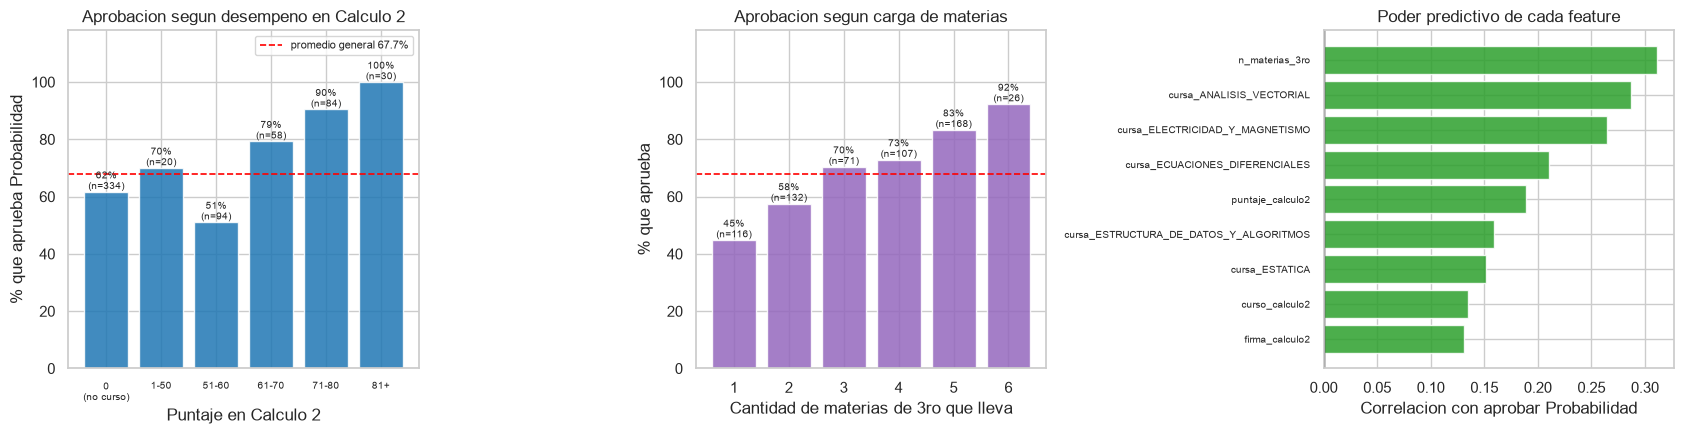

Correlacion de cada feature con el target (ordenada por magnitud):
n_materias_3ro                            0.312
cursa_ANALISIS_VECTORIAL                  0.287
cursa_ELECTRICIDAD_Y_MAGNETISMO           0.265
cursa_ECUACIONES_DIFERENCIALES            0.210
puntaje_calculo2                          0.189
cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS    0.159
cursa_ESTATICA                            0.151
curso_calculo2                            0.135
firma_calculo2                            0.131

A diferencia de un dataset sin senal, aca varias features superan 0.2 de
correlacion. Con n=620 el error estandar de una correlacion es ~0.040,
asi que esos valores estan MUY lejos de cero: hay senal real para aprender.


In [5]:
# 4 ########## Analisis exploratorio ############

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) tasa de aprobacion de Probabilidad segun el puntaje en Calculo 2
rangos = pd.cut(X["puntaje_calculo2"],
                bins=[-0.1, 0.1, 50, 60, 70, 80, 100],
                labels=["0\n(no curso)", "1-50", "51-60", "61-70", "71-80", "81+"])
tasa_p = y.groupby(rangos, observed=False).agg(["size", "mean"])
b = ax[0].bar(range(len(tasa_p)), tasa_p["mean"] * 100, color="tab:blue", alpha=.85)
ax[0].bar_label(b, labels=["%.0f%%\n(n=%d)" % (m * 100, n)
                           for n, m in zip(tasa_p["size"], tasa_p["mean"])], fontsize=7)
ax[0].axhline(y.mean() * 100, ls="--", c="red", lw=1.2, label="promedio general %.1f%%" % (y.mean() * 100))
ax[0].set_xticks(range(len(tasa_p)))
ax[0].set_xticklabels(tasa_p.index, fontsize=7)
ax[0].set_ylim(0, 118)
ax[0].set_ylabel("% que aprueba Probabilidad")
ax[0].set_xlabel("Puntaje en Calculo 2")
ax[0].set_title("Aprobacion segun desempeno en Calculo 2")
ax[0].legend(fontsize=8)

# (b) tasa de aprobacion segun cuantas materias de 3ro lleva
tasa_n = y.groupby(X["n_materias_3ro"]).agg(["size", "mean"])
b = ax[1].bar(tasa_n.index, tasa_n["mean"] * 100, color="tab:purple", alpha=.85)
ax[1].bar_label(b, labels=["%.0f%%\n(n=%d)" % (m * 100, n)
                           for n, m in zip(tasa_n["size"], tasa_n["mean"])], fontsize=7)
ax[1].axhline(y.mean() * 100, ls="--", c="red", lw=1.2)
ax[1].set_ylim(0, 118)
ax[1].set_xlabel("Cantidad de materias de 3ro que lleva")
ax[1].set_ylabel("% que aprueba")
ax[1].set_title("Aprobacion segun carga de materias")

# (c) correlacion de cada feature con el target
corr = X.assign(paso=y).corr()["paso"].drop("paso").sort_values()
colores = ["tab:red" if v < 0 else "tab:green" for v in corr]
ax[2].barh(range(len(corr)), corr.values, color=colores, alpha=.85)
ax[2].set_yticks(range(len(corr)))
ax[2].set_yticklabels(corr.index, fontsize=7)
ax[2].axvline(0, c="black", lw=1)
ax[2].set_xlabel("Correlacion con aprobar Probabilidad")
ax[2].set_title("Poder predictivo de cada feature")

plt.tight_layout()
plt.show()

print("Correlacion de cada feature con el target (ordenada por magnitud):")
print(corr.reindex(corr.abs().sort_values(ascending=False).index).round(3).to_string())
print()
print("A diferencia de un dataset sin senal, aca varias features superan 0.2 de")
print("correlacion. Con n=%d el error estandar de una correlacion es ~%.3f," % (len(X), 1 / np.sqrt(len(X))))
print("asi que esos valores estan MUY lejos de cero: hay senal real para aprender.")

In [6]:
# 4.1 ########## Respuesta descriptiva a la pregunta literal ############
# Antes de modelar: que paso con los alumnos que estan EXACTAMENTE en la
# situacion de la pregunta (firma en Calculo 2 + las 6 materias de 3ro)?

caso = X[(X["firma_calculo2"] == 1) & (X["n_materias_3ro"] == 6)]
y_caso = y.loc[caso.index]

print("Alumnos con firma en Calculo 2 Y las 6 materias de 3ro:", len(caso))
print("  aprobaron Probabilidad:", int(y_caso.sum()), "de", len(y_caso),
      "(%.1f%%)" % (y_caso.mean() * 100))
print("  contra una tasa general de %.1f%%" % (y.mean() * 100))
print()
print("El embudo completo:")
firma_c2 = set(calc2.index[calc2["FirmaCalculada"] >= UMBRAL_FIRMA])
print("  cursaron CALCULO 2                       :", len(calc2))
print("  ... con firma                            :", len(firma_c2))
print("  ... y cursan PROBABILIDAD                :", len(firma_c2 & set(prob.index)))
print("  ... y ademas llevan las 6 materias de 3ro:", len(caso))
print()
print("Los %d casos del final ya tienen las dos clases, pero siguen siendo pocos" % len(caso))
print("para entrenar: por eso el resto del notebook usa las materias y la firma")
print("como FEATURES sobre los %d alumnos, y recupera este caso en la seccion 11." % len(X))

Alumnos con firma en Calculo 2 Y las 6 materias de 3ro: 24
  aprobaron Probabilidad: 22 de 24 (91.7%)
  contra una tasa general de 67.7%

El embudo completo:
  cursaron CALCULO 2                       : 558
  ... con firma                            : 348
  ... y cursan PROBABILIDAD                : 282
  ... y ademas llevan las 6 materias de 3ro: 24

Los 24 casos del final ya tienen las dos clases, pero siguen siendo pocos
para entrenar: por eso el resto del notebook usa las materias y la firma
como FEATURES sobre los 620 alumnos, y recupera este caso en la seccion 11.


## 5. Justificación de la selección de modelos

Los tres modelos cubren tres hipótesis distintas sobre la forma de la relación, y por eso la
comparación es informativa en vez de redundante:

| Modelo | Hipótesis que asume | Qué aporta |
|---|---|---|
| **Logística elastic-net** | La probabilidad de aprobar es una función **monótona** de una combinación lineal de las features | Probabilidad calibrada e interpretable (un coeficiente por feature). La regularización elastic-net combina L2 (encoge todos los coeficientes) con L1 (anula los inútiles), y `GridSearchCV` elige la mezcla en vez de imponerla. |
| **SVM lineal** | Existe un **hiperplano** que separa las clases con margen máximo | Optimiza un criterio distinto y sirve de contraste: si coincide con la logística, la limitación es la forma lineal y no el criterio. |
| **Gradient Boosting** | La relación puede ser **no lineal y con interacciones** entre features | Es el único que puede aprender reglas del tipo *"si el puntaje está entre 51 y 60 **y** lleva pocas materias, entonces...".* Construye árboles secuencialmente, cada uno corrigiendo los errores del anterior. |

### Por qué mirar el AUC y no solo la accuracy

Las clases están desbalanceadas: el 67.7 % de los alumnos aprueba. Con ese desbalance la accuracy
es poco informativa, porque un modelo que simplemente predijera "PASA" para todos ya acertaría el
67.7 % de las veces sin haber aprendido nada.

El **ROC-AUC** no tiene ese problema: mide la capacidad de **ordenar** a los alumnos por riesgo,
es independiente del umbral de decisión, y vale 0.5 para un modelo que no distingue. Por eso es la
métrica principal de la comparación de la sección 9.

### Qué esperar de la comparación

El análisis exploratorio ya adelanta dos cosas:

1. Varias features tienen correlación superior a 0.2 con el target, así que **los modelos lineales
   deberían funcionar** — hay una componente monótona clara.
2. Pero la relación entre el puntaje de Cálculo 2 y aprobar Probabilidad **no es del todo
   monótona**, así que Gradient Boosting debería sacar alguna ventaja adicional.


In [ ]:
# 5 ########## Modelo 1: Regresion Logistica Elastic-Net ############
# Elastic-Net = mezcla de L1 (Lasso) y L2 (Ridge), controlada por l1_ratio.
# Solo el solver 'saga' la soporta.
#
# Compatibilidad: hasta sklearn 1.7 hacia falta penalty="elasticnet"; desde la
# 1.8 quedo deprecado y se pide solo con l1_ratio.
import sklearn
_v = tuple(int(n) for n in sklearn.__version__.split(".")[:2])
EN = {} if _v >= (1, 8) else {"penalty": "elasticnet"}

pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga",
        l1_ratio=0.5,
        max_iter=5000,
        random_state=RANDOM_STATE,
        **EN
    )),
])

# GridSearchCV: prueba cada combinacion con validacion cruzada de 5 folds.
#
# Se optimiza ROC-AUC y NO F1. Motivo: con clases desbalanceadas (67.7%
# positivos), el F1 de la clase positiva se maximiza prediciendo "PASA" para
# todos (recall = 1). 
grid_log = GridSearchCV(
    pipe_log,
    param_grid={
        "clf__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],   # 0 = Ridge ... 1 = Lasso
        "clf__C": [0.01, 0.1, 1.0, 10.0],               # menor C = mas regularizacion
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid_log.fit(X_train, y_train)

log_reg = grid_log.best_estimator_
print("Mejores hiperparametros:", grid_log.best_params_)
print("ROC-AUC medio en validacion cruzada: %.3f" % grid_log.best_score_)
print()

evaluar("Log. Elastic-Net", log_reg)

# Coeficientes: cuanto pesa cada feature (sobre el dato ya escalado)
coefs = pd.Series(log_reg.named_steps["clf"].coef_[0], index=X.columns)
print()
print("Coeficientes (positivo = empuja hacia APROBAR):")
print(coefs.sort_values(key=abs, ascending=False).round(3).to_string())

Mejores hiperparametros: {'clf__C': 10.0, 'clf__l1_ratio': 1.0}
ROC-AUC medio en validacion cruzada: 0.725

=== Log. Elastic-Net ===
              precision    recall  f1-score   support

     NO PASA       0.59      0.50      0.54        40
        PASA       0.78      0.83      0.80        84

    accuracy                           0.73       124
   macro avg       0.68      0.67      0.67       124
weighted avg       0.72      0.73      0.72       124

  TEST (124 filas) -> accuracy 0.726 | AUC 0.792
  CV 5-fold       -> accuracy 0.697 +/- 0.039 | AUC 0.741 +/- 0.058

Coeficientes (positivo = empuja hacia APROBAR):
puntaje_calculo2                          2.852
firma_calculo2                           -2.776
cursa_ANALISIS_VECTORIAL                  0.607
cursa_ELECTRICIDAD_Y_MAGNETISMO           0.393
cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS    0.381
cursa_ECUACIONES_DIFERENCIALES           -0.122
curso_calculo2                           -0.041
cursa_ESTATICA                        

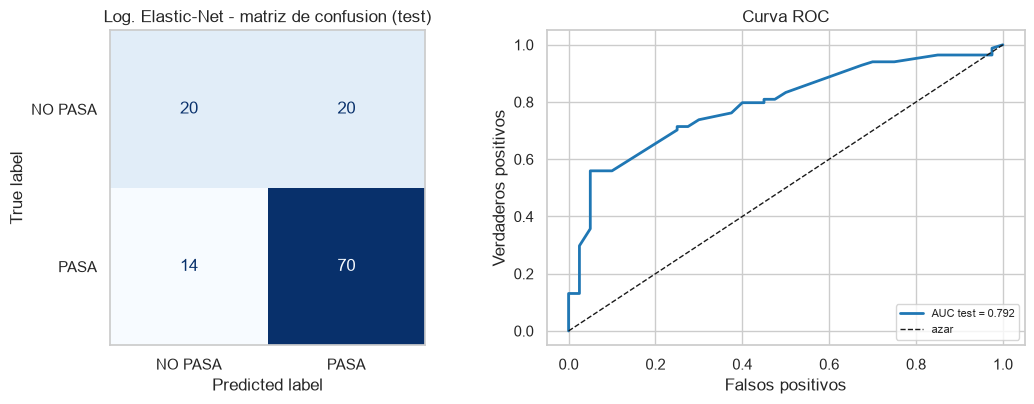

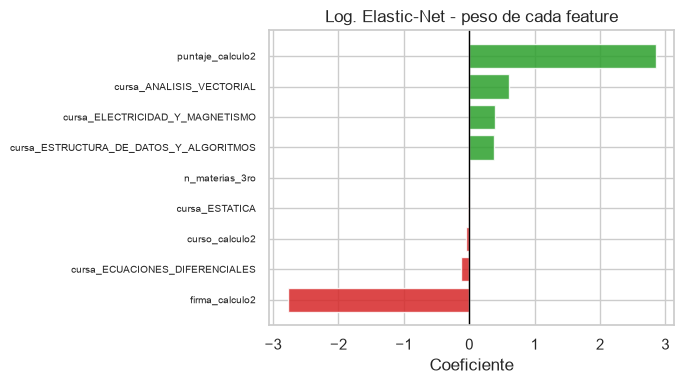

In [8]:
# 5.1 ########## Graficos Regresion Logistica ##########
graficos_modelo("Log. Elastic-Net", log_reg, color="tab:blue")

plt.figure(figsize=(7, 4))
c = coefs.sort_values()
plt.barh(range(len(c)), c.values,
         color=["tab:red" if v < 0 else "tab:green" for v in c], alpha=.85)
plt.yticks(range(len(c)), c.index, fontsize=7)
plt.axvline(0, c="black", lw=1)
plt.xlabel("Coeficiente")
plt.title("Log. Elastic-Net - peso de cada feature")
plt.tight_layout()
plt.show()

In [9]:
# 6 ########## Modelo 2: SVM lineal ############
# Busca el hiperplano que separa las clases con el margen mas ancho.
# probability=True habilita predict_proba (necesario para la curva ROC).

svm_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="linear",
        C=1.0,
        probability=True,
        random_state=RANDOM_STATE,
    )),
])

evaluar("SVM Lineal", svm_lin)

clf = svm_lin.named_steps["clf"]
print()
print("Vectores de soporte:", clf.n_support_, "( total:", int(clf.n_support_.sum()),
      "de", len(X_train), "de entrenamiento )")
print("La proporcion de vectores de soporte indica cuanto se solapan las clases:")
print("cuantos mas, menos limpia es la separacion.")

C:\Users\gatog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\gatog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\gatog\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

=== SVM Lineal ===
              precision    recall  f1-score   support

     NO PASA       0.70      0.17      0.28        40
        PASA       0.71      0.96      0.82        84

    accuracy                           0.71       124
   macro avg       0.71      0.57      0.55       124
weighted avg       0.71      0.71      0.64       124

  TEST (124 filas) -> accuracy 0.710 | AUC 0.758
  CV 5-fold       -> accuracy 0.705 +/- 0.034 | AUC 0.720 +/- 0.040

Vectores de soporte: [158 165] ( total: 323 de 496 de entrenamiento )
La proporcion de vectores de soporte indica cuanto se solapan las clases:
cuantos mas, menos limpia es la separacion.


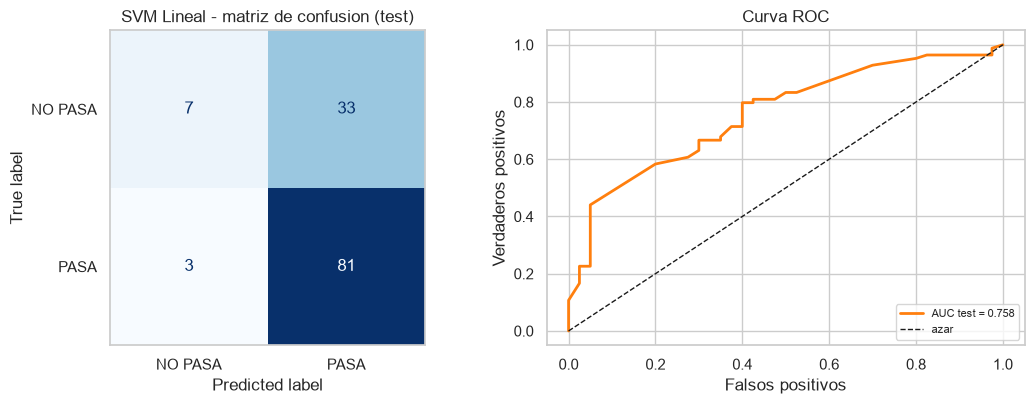

In [10]:
# 6.1 ########## Graficos SVM lineal ##########
graficos_modelo("SVM Lineal", svm_lin, color="tab:orange")

In [ ]:
# 7 ########## Modelo 3: Gradient Boosting (arboles) ############
# A diferencia de los dos modelos previos, puede capturar relaciones no lineales e interacciones entre features.

gb = GradientBoostingClassifier(
    n_estimators=100,      # cantidad de arboles
    learning_rate=0.1,     # cuanto aporta cada arbol
    max_depth=3,           # profundidad -> controla el sobreajuste
    random_state=RANDOM_STATE,
)

evaluar("Gradient Boosting", gb)

importancias = pd.Series(gb.feature_importances_, index=X.columns)
print()
print("Importancia de cada feature:")
print(importancias.sort_values(ascending=False).round(3).to_string())

=== Gradient Boosting ===
              precision    recall  f1-score   support

     NO PASA       0.58      0.38      0.45        40
        PASA       0.74      0.87      0.80        84

    accuracy                           0.71       124
   macro avg       0.66      0.62      0.63       124
weighted avg       0.69      0.71      0.69       124

  TEST (124 filas) -> accuracy 0.710 | AUC 0.782
  CV 5-fold       -> accuracy 0.726 +/- 0.020 | AUC 0.800 +/- 0.020

Importancia de cada feature:
puntaje_calculo2                          0.458
n_materias_3ro                            0.239
cursa_ELECTRICIDAD_Y_MAGNETISMO           0.078
cursa_ECUACIONES_DIFERENCIALES            0.055
curso_calculo2                            0.043
cursa_ANALISIS_VECTORIAL                  0.038
cursa_ESTRUCTURA_DE_DATOS_Y_ALGORITMOS    0.033
firma_calculo2                            0.032
cursa_ESTATICA                            0.023


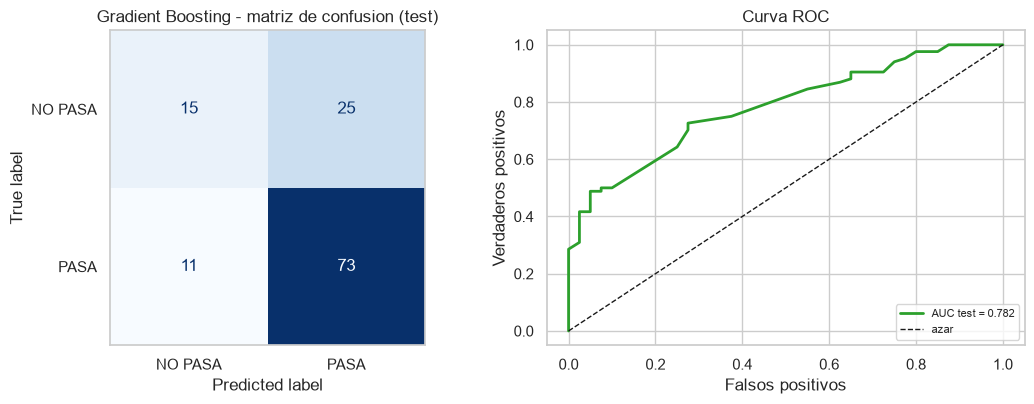

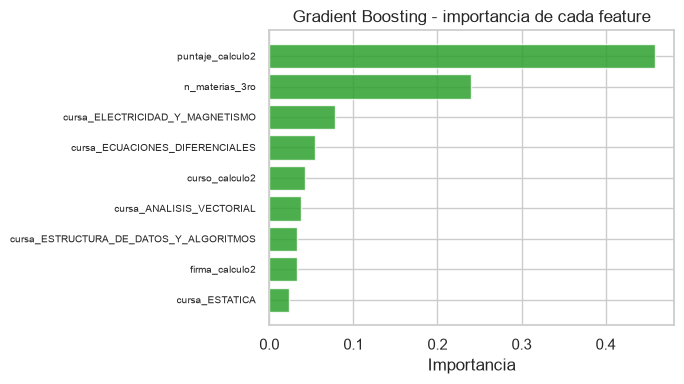

In [12]:
# 7.1 ########## Graficos Gradient Boosting ##########
graficos_modelo("Gradient Boosting", gb, color="tab:green")

plt.figure(figsize=(7, 4))
imp = importancias.sort_values()
plt.barh(range(len(imp)), imp.values, color="tab:green", alpha=.85)
plt.yticks(range(len(imp)), imp.index, fontsize=7)
plt.xlabel("Importancia")
plt.title("Gradient Boosting - importancia de cada feature")
plt.tight_layout()
plt.show()

AUC real                    : 0.800
AUC con el target barajado  : 0.505 +/- 0.031  (maximo 0.587)
p-valor                     : 0.0099

p < 0.05 -> el rendimiento NO se explica por azar: hay senal real.


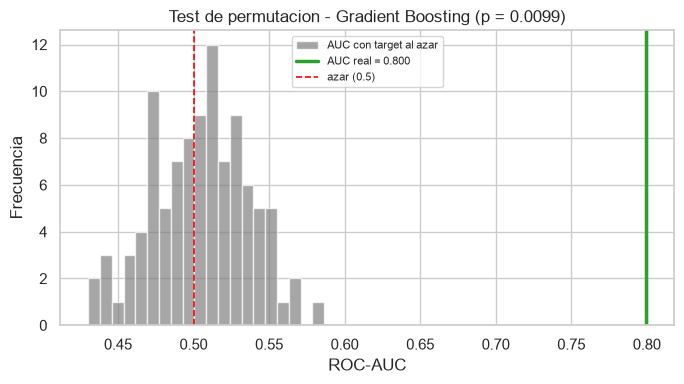

In [13]:
# 8 ########## Test de permutacion sobre Gradient Boosting ############
# Entrena el modelo 101 veces con validacion cruzada: tarda un rato.

score_real, scores_perm, pvalor = permutation_test_score(
    gb, X, y,
    cv=cv,
    scoring="roc_auc",
    n_permutations=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("AUC real                    : %.3f" % score_real)
print("AUC con el target barajado  : %.3f +/- %.3f  (maximo %.3f)" % (
    scores_perm.mean(), scores_perm.std(), scores_perm.max()))
print("p-valor                     : %.4f" % pvalor)
print()
if pvalor < 0.05:
    print("p < 0.05 -> el rendimiento NO se explica por azar: hay senal real.")
else:
    print("p >= 0.05 -> el rendimiento es compatible con el azar.")

plt.figure(figsize=(7, 4))
plt.hist(scores_perm, bins=20, color="gray", alpha=.7, label="AUC con target al azar")
plt.axvline(score_real, color="tab:green", lw=2.5,
            label="AUC real = %.3f" % score_real)
plt.axvline(0.5, color="red", ls="--", lw=1.2, label="azar (0.5)")
plt.xlabel("ROC-AUC")
plt.ylabel("Frecuencia")
plt.title("Test de permutacion - Gradient Boosting (p = %.4f)" % pvalor)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [14]:
# 9 ########## Tabla comparativa ############

df_comp = pd.DataFrame(resultados).T
orden = ["Acc test", "Prec test", "Rec test", "F1 test", "AUC test",
         "Acc CV", "Acc CV sd", "AUC CV", "AUC CV sd"]
df_comp = df_comp[orden].sort_values("AUC CV", ascending=False)

print("TABLA COMPARATIVA")
print()
print("--- Metricas sobre el test (%d filas) ---" % len(X_test))
print(df_comp[["Acc test", "Prec test", "Rec test", "F1 test", "AUC test"]].round(3).to_string())
print()
print("--- Validacion cruzada 5-fold sobre los %d alumnos (evidencia principal) ---" % len(X))
cvtab = df_comp[["Acc CV", "Acc CV sd", "AUC CV", "AUC CV sd"]].round(3)
print(cvtab.to_string())
print()

print("Ordenados por ROC-AUC en validacion cruzada:")
for i, nombre in enumerate(df_comp.index, 1):
    print("  %d. %-22s AUC %.3f +/- %.3f" % (
        i, nombre, df_comp.loc[nombre, "AUC CV"], df_comp.loc[nombre, "AUC CV sd"]))

df_comp.round(3)

TABLA COMPARATIVA

--- Metricas sobre el test (124 filas) ---
                   Acc test  Prec test  Rec test  F1 test  AUC test
Gradient Boosting     0.710      0.745     0.869    0.802     0.782
Log. Elastic-Net      0.726      0.778     0.833    0.805     0.792
SVM Lineal            0.710      0.711     0.964    0.818     0.758

--- Validacion cruzada 5-fold sobre los 620 alumnos (evidencia principal) ---
                   Acc CV  Acc CV sd  AUC CV  AUC CV sd
Gradient Boosting   0.726      0.020   0.800      0.020
Log. Elastic-Net    0.697      0.039   0.741      0.058
SVM Lineal          0.705      0.034   0.720      0.040

Ordenados por ROC-AUC en validacion cruzada:
  1. Gradient Boosting      AUC 0.800 +/- 0.020
  2. Log. Elastic-Net       AUC 0.741 +/- 0.058
  3. SVM Lineal             AUC 0.720 +/- 0.040


,Acc test,Prec test,Rec test,F1 test,AUC test,Acc CV,Acc CV sd,AUC CV,AUC CV sd
Gradient Boosting,0.710,0.745,0.869,0.802,0.782,0.726,0.020,0.800,0.020
Log. Elastic-Net,0.726,0.778,0.833,0.805,0.792,0.697,0.039,0.741,0.058
SVM Lineal,0.710,0.711,0.964,0.818,0.758,0.705,0.034,0.720,0.040


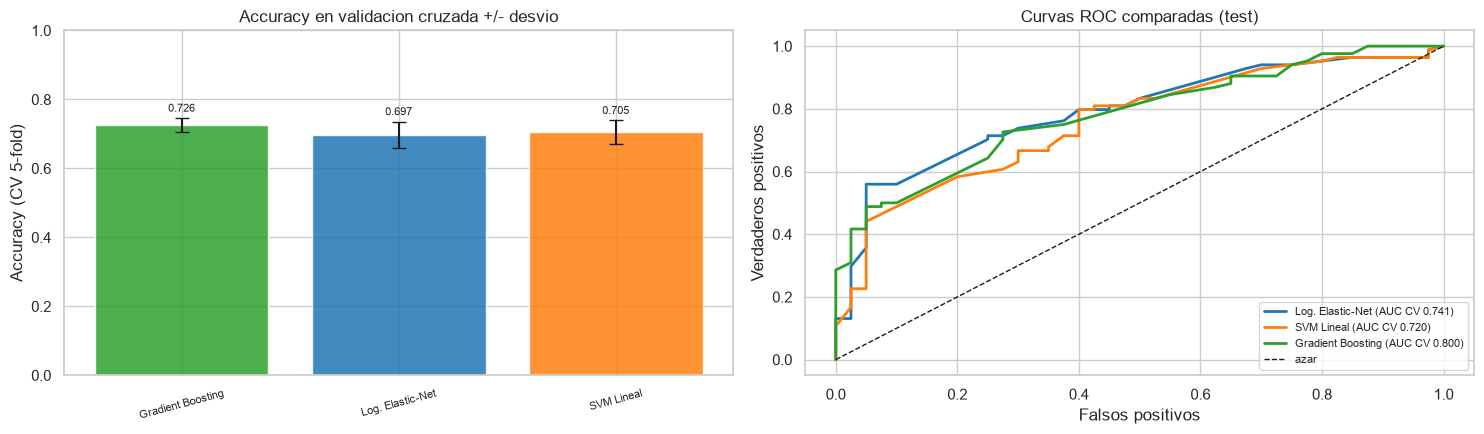

In [15]:
# 9.1 ########## Graficos comparativos ############
colores = {"Log. Elastic-Net": "tab:blue", "SVM Lineal": "tab:orange",
           "Gradient Boosting": "tab:green"}

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

# (a) accuracy en CV con barras de error
idx = [i for i in df_comp.index]
vals = df_comp["Acc CV"].values
errs = df_comp["Acc CV sd"].values
b = ax[0].bar(range(len(idx)), vals, yerr=errs, capsize=5,
              color=[colores.get(i, "tab:gray") for i in idx], alpha=.85)
ax[0].bar_label(b, fmt="%.3f", fontsize=8, padding=3)
ax[0].set_xticks(range(len(idx)))
ax[0].set_xticklabels(idx, rotation=15, fontsize=8)
ax[0].set_ylim(0, 1.0)
ax[0].set_ylabel("Accuracy (CV 5-fold)")
ax[0].set_title("Accuracy en validacion cruzada +/- desvio")

# (b) curvas ROC sobre el test
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[1].plot(fpr, tpr, lw=2, color=colores.get(nombre),
               label="%s (AUC CV %.3f)" % (nombre, resultados[nombre]["AUC CV"]))
ax[1].plot([0, 1], [0, 1], "k--", lw=1, label="azar")
ax[1].set_xlabel("Falsos positivos")
ax[1].set_ylabel("Verdaderos positivos")
ax[1].set_title("Curvas ROC comparadas (test)")
ax[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# 10 ########## Prediccion para un alumno nuevo ############

def predecir(puntaje_calculo2, materias, mostrar=True):
    """Responde PASA / NO PASA con los tres modelos.

    puntaje_calculo2 : puntaje en Calculo 2 (0 a 100). Usar 0 si no la curso.
    materias         : lista con los nombres de las materias de 3ro que lleva.
    """
    fila = pd.DataFrame(0, index=[0], columns=X.columns, dtype=float)
    fila["curso_calculo2"] = 1 if puntaje_calculo2 > 0 else 0
    fila["firma_calculo2"] = 1 if puntaje_calculo2 >= UMBRAL_FIRMA else 0
    fila["puntaje_calculo2"] = float(puntaje_calculo2)

    for m in materias:
        col = "cursa_" + m.replace(" ", "_")
        if col in fila.columns:
            fila[col] = 1
    fila["n_materias_3ro"] = int(fila[cols_cursa].sum(axis=1).iloc[0]) + 1

    filas = []
    for nombre, modelo in modelos.items():
        p = float(modelo.predict_proba(fila)[0, 1])
        # La etiqueta se deriva de la probabilidad y NO de modelo.predict().
        # Motivo: en SVC con probability=True, predict() usa la funcion de
        # decision mientras predict_proba() usa un ajuste de Platt calibrado
        # aparte por validacion cruzada interna. Los dos pueden discrepar.
        # Usar el mismo criterio para todos evita mostrar "82% -> NO PASA".
        filas.append({
            "Modelo": nombre,
            "P(pasa) %": round(p * 100, 1),
            "Resultado": "PASA" if p >= 0.5 else "NO PASA",
        })
    salida = pd.DataFrame(filas).set_index("Modelo")

    if mostrar:
        print("Calculo 2: %s pts (%s firma) | %d materias de 3ro" % (
            puntaje_calculo2,
            "con" if fila["firma_calculo2"].iloc[0] else "sin",
            int(fila["n_materias_3ro"].iloc[0])))
        print(salida.to_string())
        print()
    return salida


# --- El caso exacto de la pregunta del parcial -----------------------------
otras5 = [m for m in MATERIAS_3RO if m != "PROBABILIDAD"]
print(">>> CASO DE LA PREGUNTA: firma en Calculo 2 (60 pts) + las 6 materias de 3ro")
predecir(60, otras5)

print(">>> Comparacion con otros escenarios")
predecir(85, otras5)                  # buena nota en Calculo 2, carga completa
predecir(55, otras5[:2])              # firma justa, pocas materias
predecir(0, otras5[:2])               # no curso Calculo 2

>>> CASO DE LA PREGUNTA: firma en Calculo 2 (60 pts) + las 6 materias de 3ro
Calculo 2: 60 pts (con firma) | 6 materias de 3ro
                   P(pasa) % Resultado
Modelo                                
Log. Elastic-Net        92.4      PASA
SVM Lineal              81.8      PASA
Gradient Boosting       74.1      PASA

>>> Comparacion con otros escenarios
Calculo 2: 85 pts (con firma) | 6 materias de 3ro
                   P(pasa) % Resultado
Modelo                                
Log. Elastic-Net        99.0      PASA
SVM Lineal              83.9      PASA
Gradient Boosting       99.5      PASA

Calculo 2: 55 pts (con firma) | 3 materias de 3ro
                   P(pasa) % Resultado
Modelo                                
Log. Elastic-Net        39.1   NO PASA
SVM Lineal              55.1      PASA
Gradient Boosting       78.9      PASA

Calculo 2: 0 pts (sin firma) | 3 materias de 3ro
                   P(pasa) % Resultado
Modelo                                
Log. Elastic-Net     

,P(pasa) %,Resultado
Modelo,,
Log. Elastic-Net,62.9,PASA
SVM Lineal,70.1,PASA
Gradient Boosting,66.0,PASA


## 11. Conclusiones

### Respuesta a la pregunta

**Sí, tener firma en Cálculo 2 mejora las chances de aprobar Probabilidad, pero no es el factor más
importante.** Los números del conjunto :

| | % que aprueba Probabilidad |
|---|---|
| Con firma en Cálculo 2 | **74.5 %** |
| Sin firma | 62.1 % |
| Tasa general | 67.7 % |

Son 12.4 puntos de diferencia, en la dirección esperada. Pero **lo que más predice es la carga de
materias**: `n_materias_3ro` es la feature con mayor correlación con el target (0.312), por encima
de `firma_calculo2` (0.131).

Y para el caso exacto de la pregunta —firma en Cálculo 2 **y** las 6 materias de 3º— la tasa
observada sube a **91.7 %** (24 alumnos).

Hay que tener cuidado con la interpretación causal: llevar más materias no *causa* aprobar. Lo más
probable es que la cantidad de materias sea un **indicador indirecto** de la situación del alumno

### Lo que pasó con los modelos

| Modelo | Accuracy CV | AUC CV |
|---|---|---|
| Logística elastic-net | 0.697 | 0.741 |
| SVM lineal | 0.705 | 0.720 |
| **Gradient Boosting** | **0.726** | **0.800** |

Las diferencias de **AUC** son las que mejor los separan: 0.800 contra 0.741 y 0.720. La accuracy
los muestra mucho más parecidos porque con clases desbalanceadas (67.7 % positivos) es una métrica
poco sensible — otra razón para apoyarse en el AUC.

### Un detalle metodológico que cambió el resultado

La primera versión de este notebook optimizaba el `GridSearchCV` de la logística con
`scoring="f1"`, y el modelo **degeneraba en predecir "PASA" para todos** (accuracy 0.677, todos
los coeficientes aplastados a ~0.02).

El motivo es que con el 67.7 % de casos positivos, el F1 de la clase positiva se maximiza
prediciendo "PASA" para todo el mundo: así el recall vale 1 y la precision iguala la proporción de
aprobados. La búsqueda elegía entonces `C = 0.01`, la regularización más fuerte de la grilla,
aplastando el modelo.

Cambiar el criterio a `scoring="roc_auc"` —que es independiente del umbral y no premia esa solución
degenerada— hizo que eligiera `C = 10.0` con `l1_ratio = 1.0` (Lasso puro) y recuperara AUC 0.741.

Que Gradient Boosting saque ventaja adicional confirma lo otro: **hay estructura no lineal que los
lineales no pueden ver**. Se aprecia en el gráfico de aprobación por puntaje de Cálculo 2: la
relación crece de forma sostenida desde los 60 puntos (79.3 % → 90.5 % → 100 %), pero el tramo
**51-60 rompe la tendencia** con apenas 51.1 %, por debajo incluso de quienes ni siquiera cursaron
Cálculo 2 (61.7 %).

Es un hallazgo interesante en sí mismo: **conseguir la firma raspando parece peor señal que no
haber cursado la materia todavía**. Un modelo lineal está obligado a promediar ese tramo dentro de
una tendencia creciente; los árboles pueden aislarlo con un corte.

### Contraste con el Tema 1

| | Tema 1 (Primer parcial → aprobar) | Tema 2 (Cálculo 2 → Probabilidad) |
|---|---|---|
| Features | 1 (el puntaje) | 9 (desempeño previo + carga de materias) |
| Relación | monótona y fuerte | monótona con un tramo que la rompe |
| Modelos lineales | ganan (AUC 0.857) | funcionan (AUC 0.720-0.741) |
| Modelo flexible | no aporta nada | **aporta**: AUC 0.800 |
| Qué limita el resultado | el dato (techo de Bayes 0.7999) | el solapamiento entre clases |

La lección metodológica es la misma en los dos temas: **no existe un "mejor modelo" en abstracto.**
En el Tema 1, con un solo feature y relación monótona, el modelo flexible no tenía nada que aportar.
Acá, con varias features e interacciones, sí lo tiene. Por eso comparar varios modelos es parte del
método y no un agregado decorativo.
